<a href="https://colab.research.google.com/github/srikanth713/Machine_Learning/blob/main/Student_PassFail_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Student Pass/Fail Prediction Using Deep Learning

---

| | |
|---|---|
| **Project Title** | Student Pass/Fail Prediction Using Deep Learning |
| **Dataset** | Student Performance Prediction Dataset (Kaggle) |
| **Model** | Deep Neural Network (TensorFlow / Keras) |
| **Task** | Binary Classification — PASS or FAIL |
| **Key Features** | Attendance Rate · Study Hours · Exam Scores |

---

## 📌 Project Overview

This notebook builds a **competition-grade deep learning pipeline** to predict whether a student will **PASS or FAIL** based on academic and behavioural indicators. The workflow covers:

1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Feature Engineering
4. Deep Learning Model Architecture
5. Training with Callbacks
6. Evaluation & Metrics
7. Feature Importance Analysis
8. Real-Time Prediction Interface
9. Model Persistence
10. Conclusions & Future Work

---
## 📦 Section 1 — Install & Import Libraries

In [ ]:
# ── Install any missing packages (Colab already has most) ──────────────────
!pip install -q scikit-learn tensorflow matplotlib seaborn pandas numpy

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import warnings
import os
import random

warnings.filterwarnings('ignore')

# ── Numerical & data ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.inspection import permutation_importance

# ── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# ── Reproducibility seed ───────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'Pass': '#2ecc71', 'Fail': '#e74c3c'}

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("\n✅ All libraries imported successfully.")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2

✅ All libraries imported successfully.


---
## 📂 Section 2 — Load Dataset

In [2]:
# ── Upload the CSV when running on Colab ──────────────────────────────────
# If running locally, set CSV_PATH to your file path instead.

try:
    from google.colab import files
    print("📤 Please upload 'student_performance_dataset.csv' ...")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f"   File uploaded: {CSV_PATH}")
except Exception:
    # Fallback for local execution
    CSV_PATH = 'student_performance_dataset.csv'
    print(f"Running locally — using: {CSV_PATH}")

# ── Load ───────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)
df = df_raw.copy()          # keep a pristine copy for reference

print(f"\n✅ Dataset loaded successfully.")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

📤 Please upload 'student_performance_dataset.csv' ...


Saving student_performance_dataset (1).csv to student_performance_dataset (1).csv
   File uploaded: student_performance_dataset (1).csv

✅ Dataset loaded successfully.
   Rows: 708  |  Columns: 10


---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

In [3]:
# ── 3.1  Basic Overview ────────────────────────────────────────────────────
print("═" * 55)
print("  DATASET OVERVIEW")
print("═" * 55)
print(f"Shape          : {df.shape}")
print(f"Total cells    : {df.size:,}")
print()
print("Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

═══════════════════════════════════════════════════════
  DATASET OVERVIEW
═══════════════════════════════════════════════════════
Shape          : (708, 10)
Total cells    : 7,080

Column names:
   1. Student_ID
   2. Gender
   3. Study_Hours_per_Week
   4. Attendance_Rate
   5. Past_Exam_Scores
   6. Parental_Education_Level
   7. Internet_Access_at_Home
   8. Extracurricular_Activities
   9. Final_Exam_Score
  10. Pass_Fail


In [4]:
# ── 3.2  Data Types ────────────────────────────────────────────────────────
print("═" * 55)
print("  DATA TYPES & NON-NULL COUNTS")
print("═" * 55)
df.info()

═══════════════════════════════════════════════════════
  DATA TYPES & NON-NULL COUNTS
═══════════════════════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [5]:
# ── 3.3  Missing Values ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print("═" * 45)
print("  MISSING VALUES REPORT")
print("═" * 45)
print(missing_df.to_string())
print()
if missing.sum() == 0:
    print("✅ No missing values found — dataset is clean!")
else:
    print(f"⚠️  Total missing cells: {missing.sum()}")

═════════════════════════════════════════════
  MISSING VALUES REPORT
═════════════════════════════════════════════
                            Missing Count  Missing (%)
Student_ID                              0          0.0
Gender                                  0          0.0
Study_Hours_per_Week                    0          0.0
Attendance_Rate                         0          0.0
Past_Exam_Scores                        0          0.0
Parental_Education_Level                0          0.0
Internet_Access_at_Home                 0          0.0
Extracurricular_Activities              0          0.0
Final_Exam_Score                        0          0.0
Pass_Fail                               0          0.0

✅ No missing values found — dataset is clean!


In [6]:
# ── 3.4  Statistical Summary ───────────────────────────────────────────────
print("═" * 55)
print("  STATISTICAL SUMMARY — NUMERICAL FEATURES")
print("═" * 55)
display(df.describe().round(2))

print("\n" + "═" * 55)
print("  TARGET DISTRIBUTION")
print("═" * 55)
vc = df['Pass_Fail'].value_counts()
for label, count in vc.items():
    pct = count / len(df) * 100
    print(f"  {label:4s} : {count:4d}  ({pct:.1f}%)")

═══════════════════════════════════════════════════════
  STATISTICAL SUMMARY — NUMERICAL FEATURES
═══════════════════════════════════════════════════════


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.00,708.00,708.00,708.00
mean,26.13,78.11,77.87,58.77
std,8.88,13.80,14.40,6.71
min,10.00,50.12,50.00,50.00
25%,19.00,67.55,65.00,52.00
50%,27.00,79.36,79.00,59.50
75%,34.00,89.50,91.00,64.00
max,39.00,99.97,100.00,77.00



═══════════════════════════════════════════════════════
  TARGET DISTRIBUTION
═══════════════════════════════════════════════════════
  Pass :  354  (50.0%)
  Fail :  354  (50.0%)


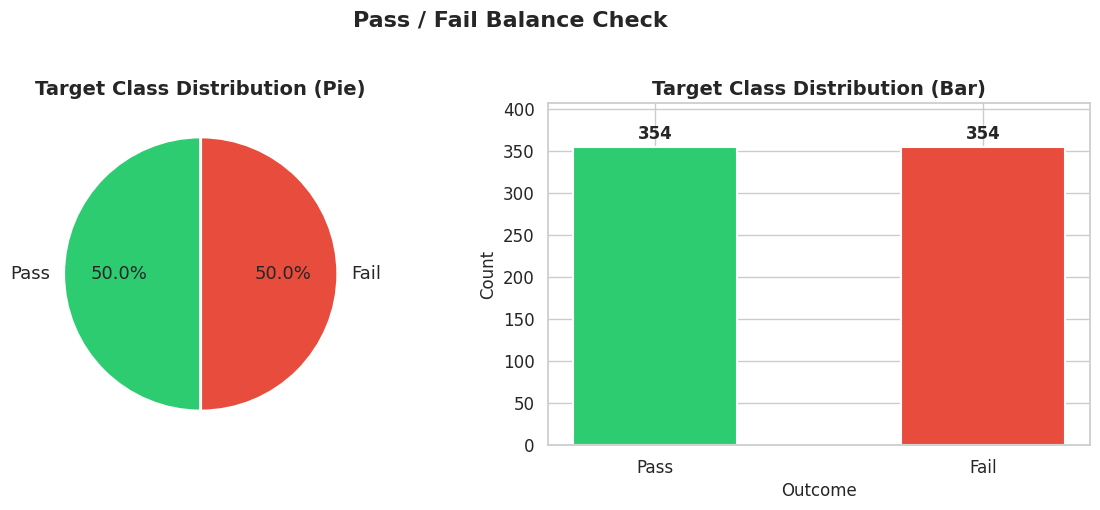

✅ Dataset is perfectly balanced (354 Pass / 354 Fail).


In [7]:
# ── 3.5  Target Class Distribution (pie + bar) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vc = df['Pass_Fail'].value_counts()
colors = [PALETTE[k] for k in vc.index]

# Pie chart
axes[0].pie(
    vc.values, labels=vc.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13}
)
axes[0].set_title('Target Class Distribution (Pie)', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(vc.index, vc.values, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
for bar, val in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Target Class Distribution (Bar)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Outcome', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_ylim(0, vc.values.max() * 1.15)

plt.suptitle('Pass / Fail Balance Check', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset is perfectly balanced (354 Pass / 354 Fail).")

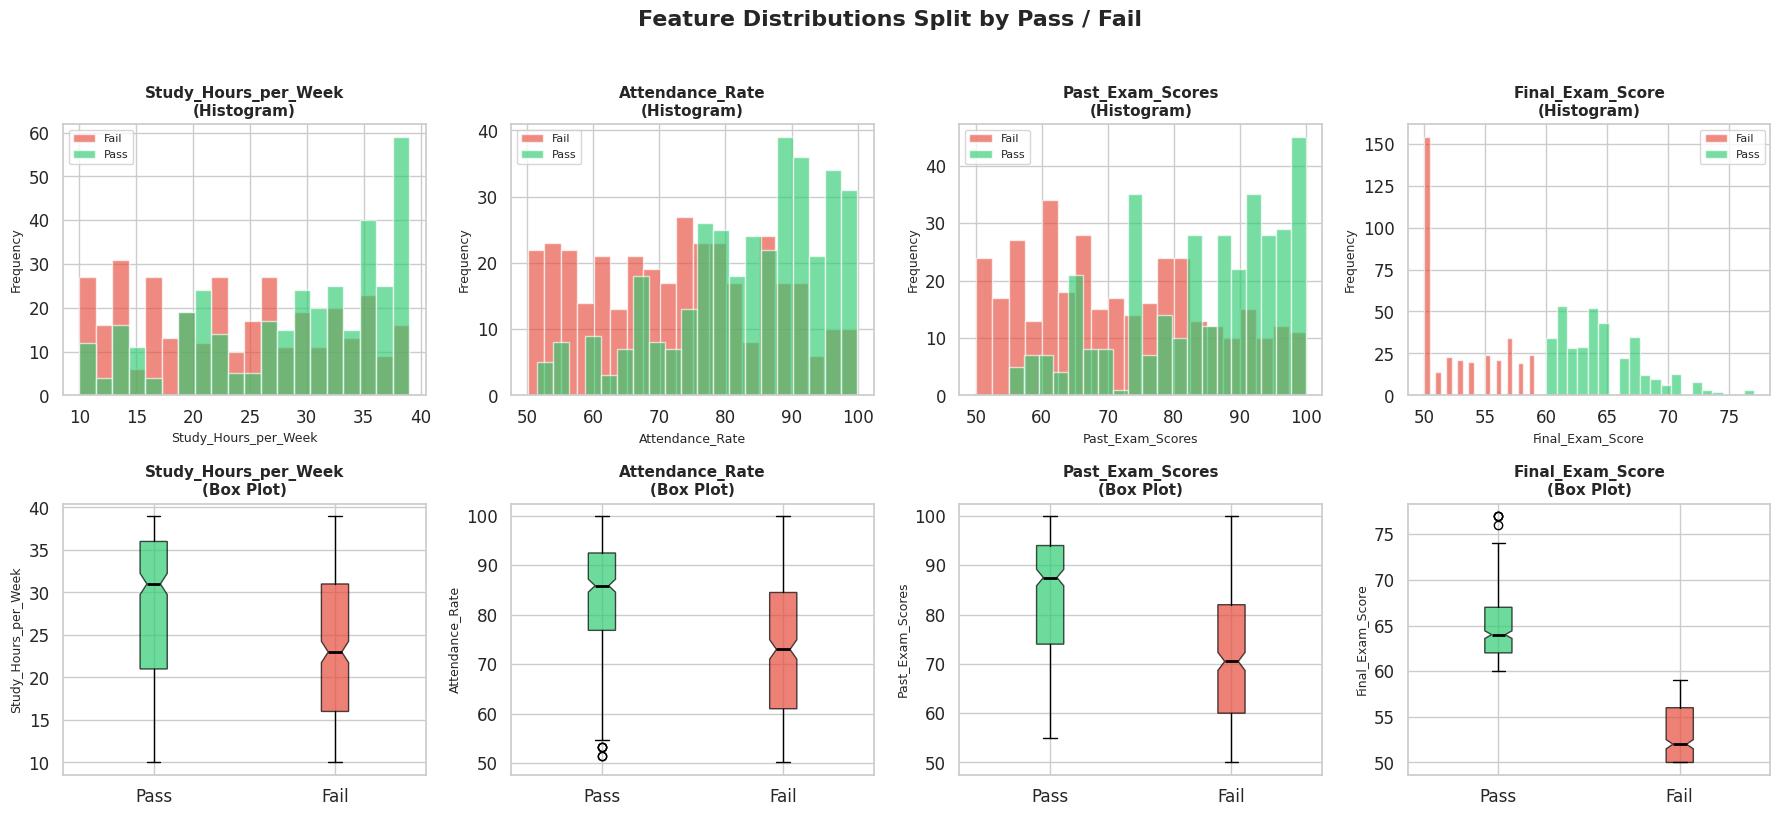

In [8]:
# ── 3.6  Feature Distributions (numerical) ────────────────────────────────
num_cols = ['Study_Hours_per_Week', 'Attendance_Rate',
            'Past_Exam_Scores', 'Final_Exam_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    ax_hist = axes[0, i]
    for outcome, grp in df.groupby('Pass_Fail'):
        ax_hist.hist(grp[col], bins=20, alpha=0.65,
                     label=outcome, color=PALETTE[outcome], edgecolor='white')
    ax_hist.set_title(f'{col}\n(Histogram)', fontsize=11, fontweight='bold')
    ax_hist.set_xlabel(col, fontsize=9)
    ax_hist.set_ylabel('Frequency', fontsize=9)
    ax_hist.legend(fontsize=8)

    # Box plot
    ax_box = axes[1, i]
    data_pass = df[df['Pass_Fail'] == 'Pass'][col]
    data_fail = df[df['Pass_Fail'] == 'Fail'][col]
    bp = ax_box.boxplot([data_pass, data_fail], labels=['Pass', 'Fail'],
                        patch_artist=True, notch=True,
                        medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], [PALETTE['Pass'], PALETTE['Fail']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_box.set_title(f'{col}\n(Box Plot)', fontsize=11, fontweight='bold')
    ax_box.set_ylabel(col, fontsize=9)

plt.suptitle('Feature Distributions Split by Pass / Fail',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

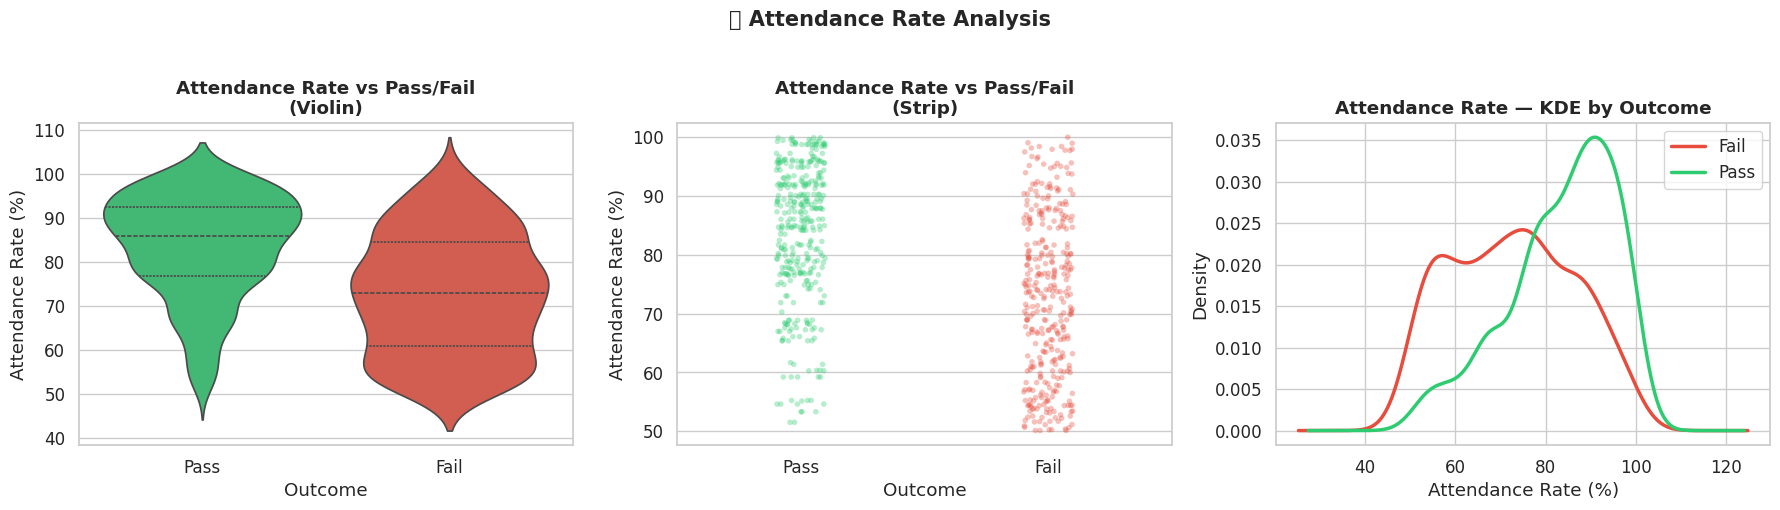

In [9]:
# ── 3.7  Attendance Rate vs Pass/Fail ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin
sns.violinplot(
    data=df, x='Pass_Fail', y='Attendance_Rate',
    palette=PALETTE, inner='quartile', ax=axes[0]
)
axes[0].set_title('Attendance Rate vs Pass/Fail\n(Violin)', fontweight='bold')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Attendance Rate (%)')

# Strip plot
sns.stripplot(
    data=df, x='Pass_Fail', y='Attendance_Rate',
    palette=PALETTE, alpha=0.35, jitter=True, size=4, ax=axes[1]
)
axes[1].set_title('Attendance Rate vs Pass/Fail\n(Strip)', fontweight='bold')
axes[1].set_xlabel('Outcome'); axes[1].set_ylabel('Attendance Rate (%)')

# KDE
for outcome, grp in df.groupby('Pass_Fail'):
    grp['Attendance_Rate'].plot.kde(
        ax=axes[2], label=outcome, color=PALETTE[outcome], linewidth=2.5
    )
axes[2].set_title('Attendance Rate — KDE by Outcome', fontweight='bold')
axes[2].set_xlabel('Attendance Rate (%)')
axes[2].legend()

plt.suptitle('🎯 Attendance Rate Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('attendance_vs_passfail.png', dpi=150, bbox_inches='tight')
plt.show()

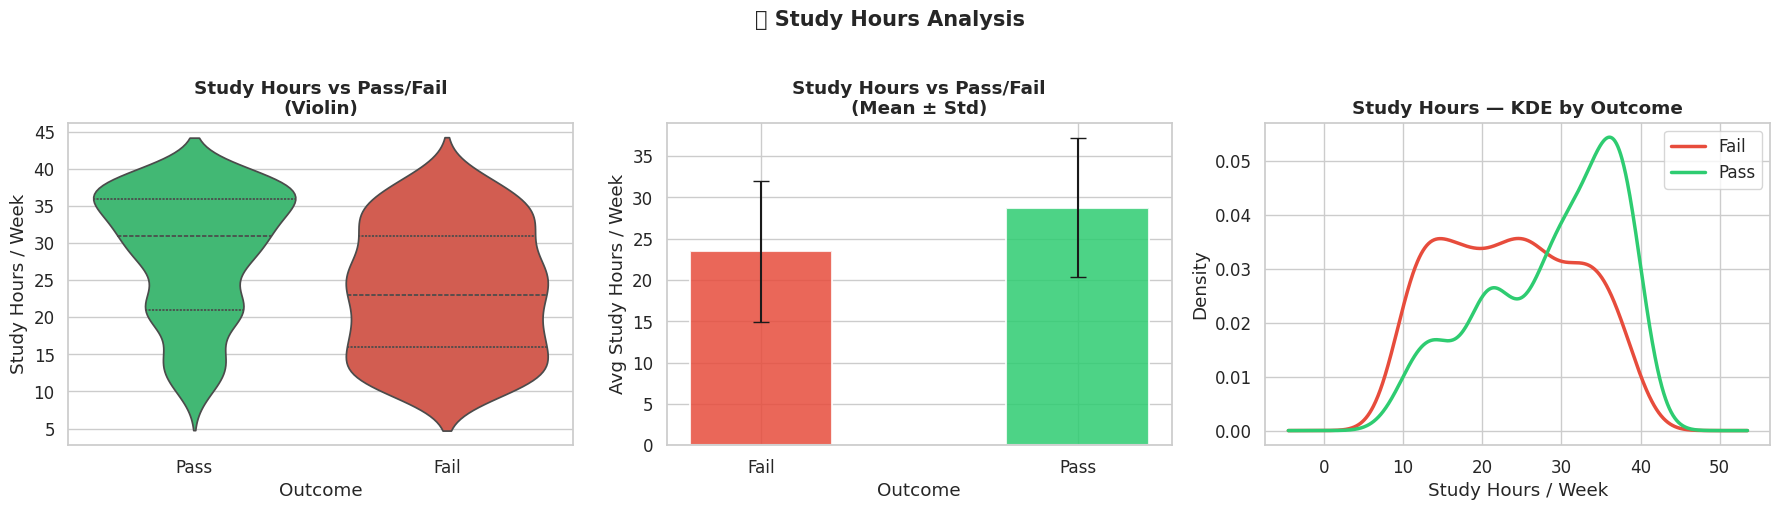

In [10]:
# ── 3.8  Study Hours vs Pass/Fail ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin
sns.violinplot(
    data=df, x='Pass_Fail', y='Study_Hours_per_Week',
    palette=PALETTE, inner='quartile', ax=axes[0]
)
axes[0].set_title('Study Hours vs Pass/Fail\n(Violin)', fontweight='bold')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Study Hours / Week')

# Bar (mean ± std)
means = df.groupby('Pass_Fail')['Study_Hours_per_Week'].mean()
stds  = df.groupby('Pass_Fail')['Study_Hours_per_Week'].std()
axes[1].bar(means.index, means.values,
            yerr=stds.values, capsize=6,
            color=[PALETTE[k] for k in means.index],
            edgecolor='white', linewidth=1.5, alpha=0.85, width=0.45)
axes[1].set_title('Study Hours vs Pass/Fail\n(Mean ± Std)', fontweight='bold')
axes[1].set_xlabel('Outcome'); axes[1].set_ylabel('Avg Study Hours / Week')

# KDE
for outcome, grp in df.groupby('Pass_Fail'):
    grp['Study_Hours_per_Week'].plot.kde(
        ax=axes[2], label=outcome, color=PALETTE[outcome], linewidth=2.5
    )
axes[2].set_title('Study Hours — KDE by Outcome', fontweight='bold')
axes[2].set_xlabel('Study Hours / Week')
axes[2].legend()

plt.suptitle('📚 Study Hours Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('study_hours_vs_passfail.png', dpi=150, bbox_inches='tight')
plt.show()

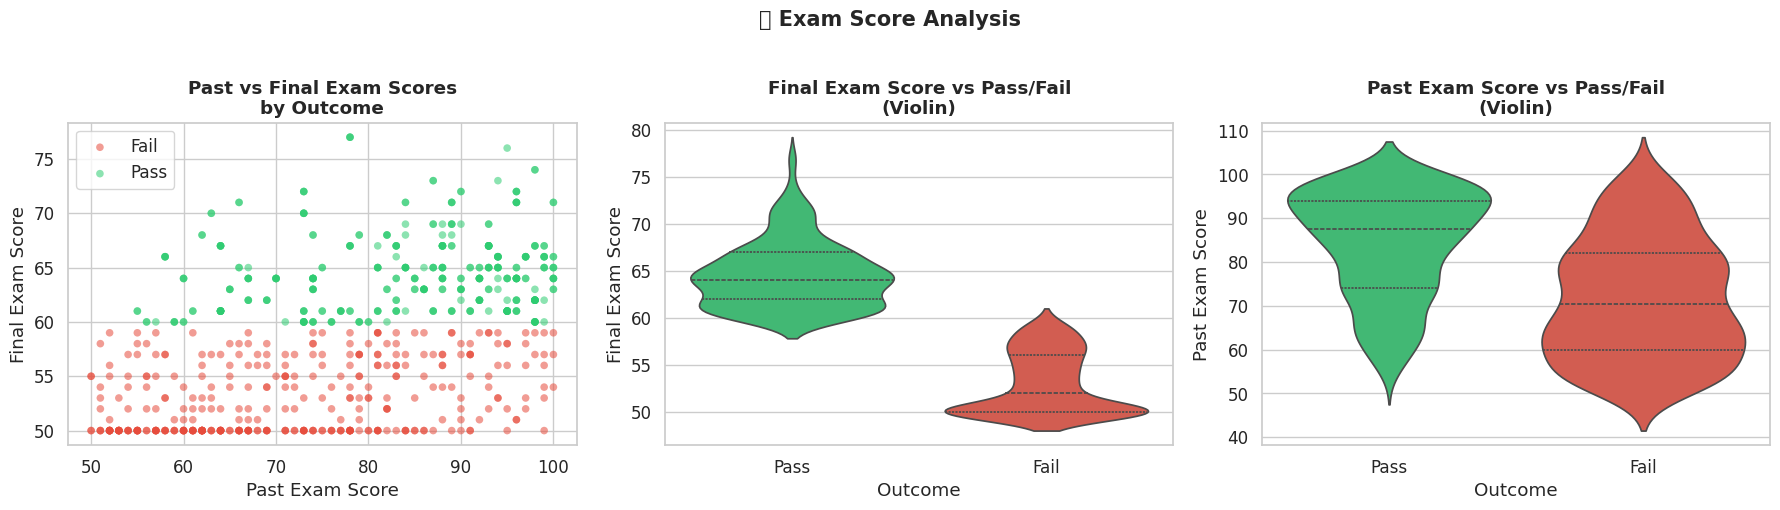

In [11]:
# ── 3.9  Exam Scores vs Pass/Fail ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Past vs Final scatter
for outcome, grp in df.groupby('Pass_Fail'):
    axes[0].scatter(
        grp['Past_Exam_Scores'], grp['Final_Exam_Score'],
        label=outcome, color=PALETTE[outcome], alpha=0.55, s=30, edgecolors='none'
    )
axes[0].set_title('Past vs Final Exam Scores\nby Outcome', fontweight='bold')
axes[0].set_xlabel('Past Exam Score'); axes[0].set_ylabel('Final Exam Score')
axes[0].legend()

# Violin — Final Exam Score
sns.violinplot(
    data=df, x='Pass_Fail', y='Final_Exam_Score',
    palette=PALETTE, inner='quartile', ax=axes[1]
)
axes[1].set_title('Final Exam Score vs Pass/Fail\n(Violin)', fontweight='bold')
axes[1].set_xlabel('Outcome'); axes[1].set_ylabel('Final Exam Score')

# Violin — Past Exam Score
sns.violinplot(
    data=df, x='Pass_Fail', y='Past_Exam_Scores',
    palette=PALETTE, inner='quartile', ax=axes[2]
)
axes[2].set_title('Past Exam Score vs Pass/Fail\n(Violin)', fontweight='bold')
axes[2].set_xlabel('Outcome'); axes[2].set_ylabel('Past Exam Score')

plt.suptitle('📝 Exam Score Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exam_scores_vs_passfail.png', dpi=150, bbox_inches='tight')
plt.show()

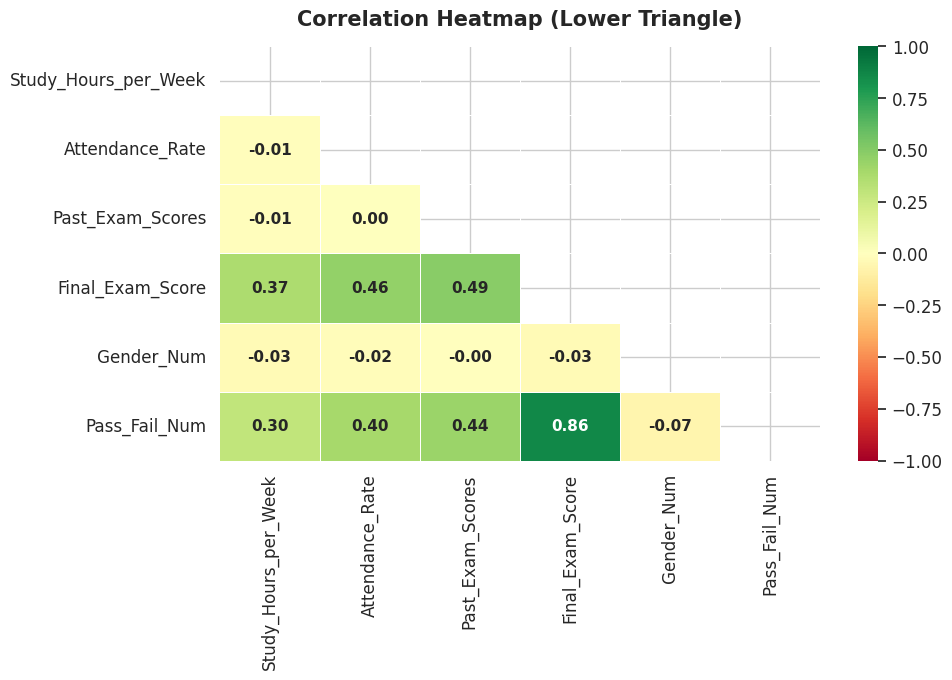


📊 Correlations with Pass/Fail (sorted):
  Final_Exam_Score               +█████████████████████████ +0.864
  Past_Exam_Scores               +█████████████ +0.437
  Attendance_Rate                +███████████ +0.396
  Study_Hours_per_Week           +████████ +0.297
  Gender_Num                     -█ -0.065


In [12]:
# ── 3.10  Correlation Heatmap ──────────────────────────────────────────────
# Encode target temporarily for correlation
df_corr = df.copy()
df_corr['Pass_Fail_Num'] = (df_corr['Pass_Fail'] == 'Pass').astype(int)
df_corr['Gender_Num'] = LabelEncoder().fit_transform(df_corr['Gender'])

num_for_corr = [
    'Study_Hours_per_Week', 'Attendance_Rate',
    'Past_Exam_Scores', 'Final_Exam_Score',
    'Gender_Num', 'Pass_Fail_Num'
]
corr = df_corr[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 11, 'weight': 'bold'}
)
ax.set_title('Correlation Heatmap (Lower Triangle)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlations with Pass/Fail (sorted):")
target_corr = corr['Pass_Fail_Num'].drop('Pass_Fail_Num').sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f"  {feat:<30s} {sign}{bar} {val:+.3f}")

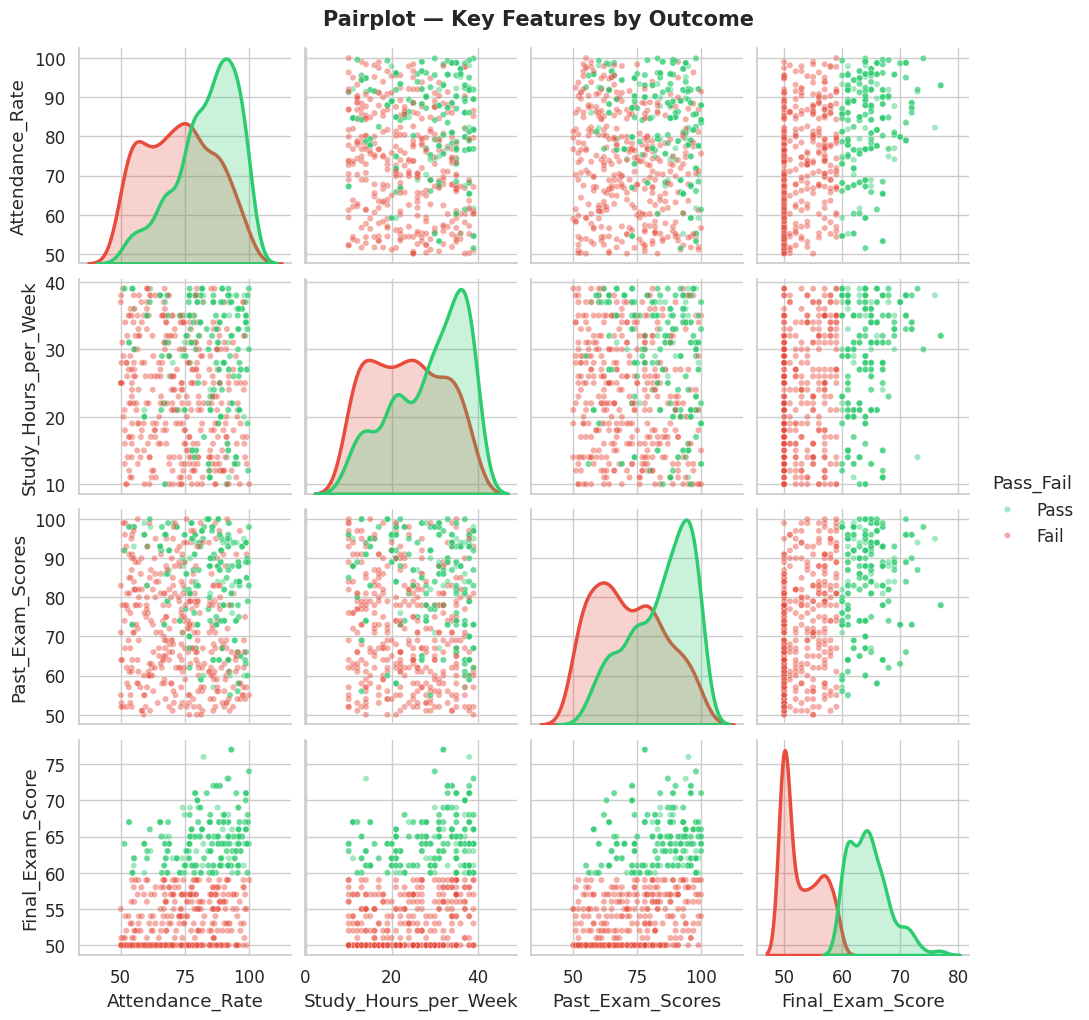

In [13]:
# ── 3.11  Pairplot of Key Features ────────────────────────────────────────
key_cols = ['Attendance_Rate', 'Study_Hours_per_Week',
            'Past_Exam_Scores', 'Final_Exam_Score', 'Pass_Fail']

g = sns.pairplot(
    df[key_cols], hue='Pass_Fail', palette=PALETTE,
    diag_kind='kde', plot_kws={'alpha': 0.45, 's': 20},
    diag_kws={'linewidth': 2.5}
)
g.figure.suptitle('Pairplot — Key Features by Outcome',
                   fontsize=15, fontweight='bold', y=1.02)
plt.savefig('pairplot.png', dpi=130, bbox_inches='tight')
plt.show()

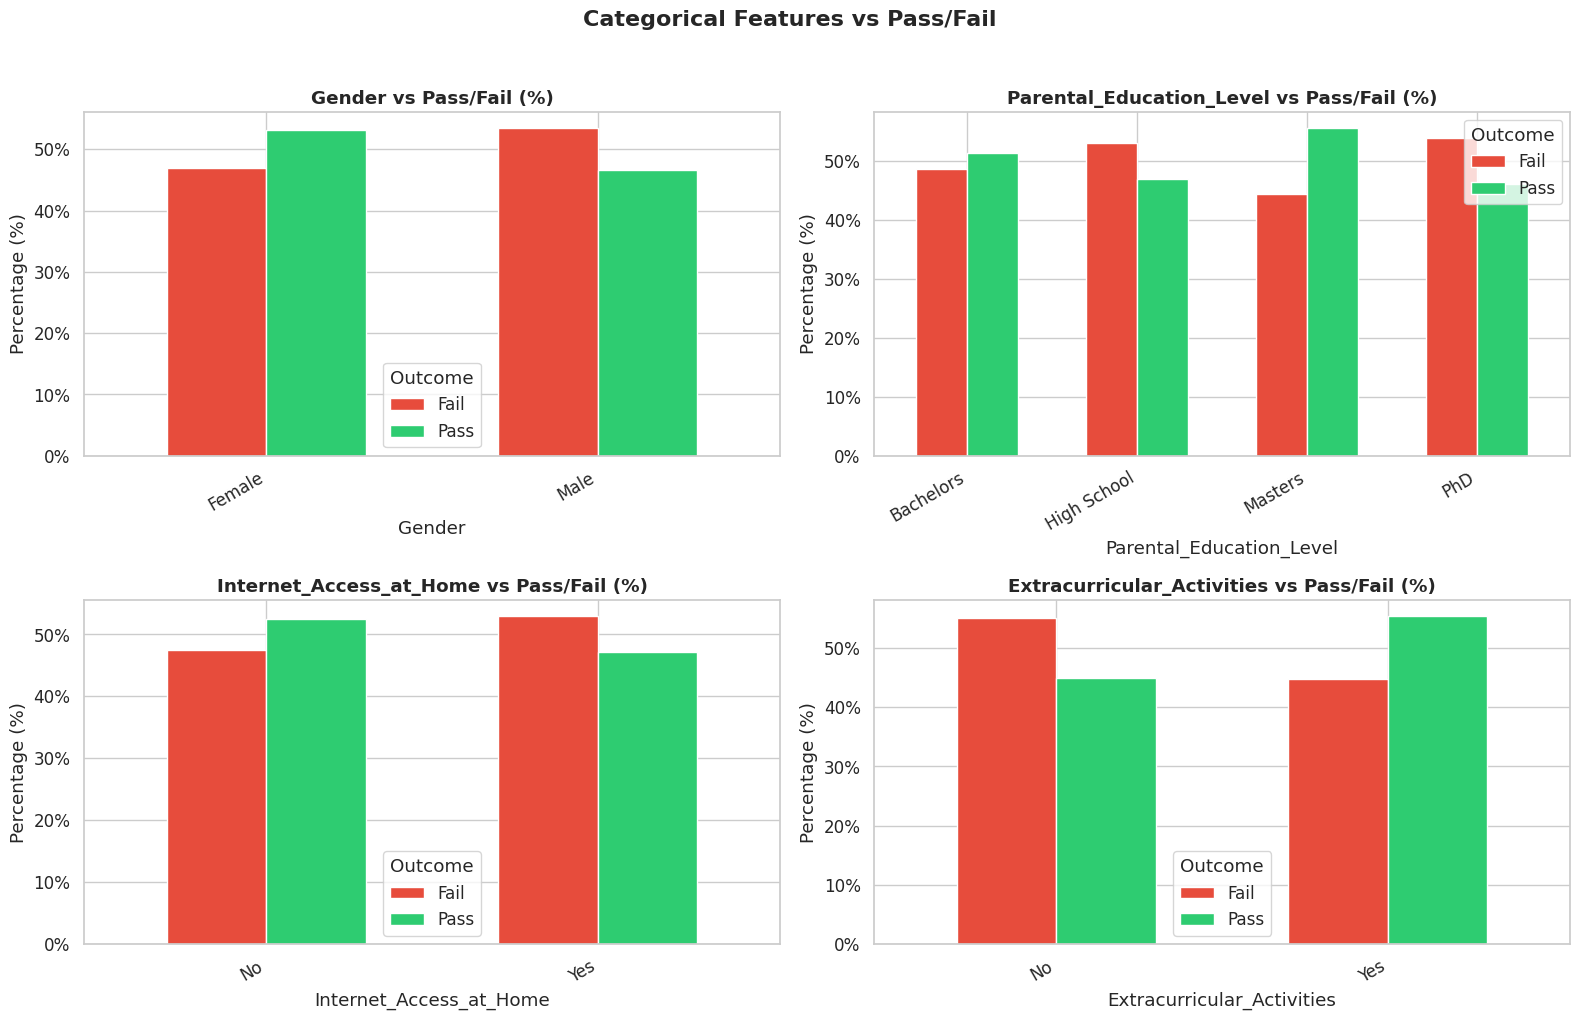

In [14]:
# ── 3.12  Categorical Features vs Pass/Fail ────────────────────────────────
cat_cols = ['Gender', 'Parental_Education_Level',
            'Internet_Access_at_Home', 'Extracurricular_Activities']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Pass_Fail'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(
        kind='bar', ax=ax,
        color=[PALETTE['Fail'], PALETTE['Pass']],
        edgecolor='white', linewidth=1, width=0.6
    )
    ax.set_title(f'{col} vs Pass/Fail (%)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Outcome', labels=['Fail', 'Pass'])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Categorical Features vs Pass/Fail',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🛠️ Section 4 — Data Preprocessing

In [15]:
# ── 4.1  Duplicate Removal ────────────────────────────────────────────────
dups = df.duplicated().sum()
print(f"Duplicate rows found: {dups}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after de-duplication: {df.shape}")

# ── 4.2  Handle Missing Values ─────────────────────────────────────────────
# (Already confirmed none exist, but we handle defensively)
num_cols_fill = ['Study_Hours_per_Week', 'Attendance_Rate',
                 'Past_Exam_Scores', 'Final_Exam_Score']
cat_cols_fill = ['Gender', 'Parental_Education_Level',
                 'Internet_Access_at_Home', 'Extracurricular_Activities']

for col in num_cols_fill:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_cols_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values remaining: {df.isnull().sum().sum()}")

# ── 4.3  Encode Target Column ──────────────────────────────────────────────
# Pass → 1,  Fail → 0
df['Target'] = (df['Pass_Fail'] == 'Pass').astype(int)
print(f"\nTarget encoding: Pass=1, Fail=0")
print(df['Target'].value_counts())

# ── 4.4  Encode Categorical Features ──────────────────────────────────────
le = LabelEncoder()
df['Gender_Enc']             = le.fit_transform(df['Gender'])
df['ParentEdu_Enc']          = le.fit_transform(df['Parental_Education_Level'])
df['Internet_Enc']           = le.fit_transform(df['Internet_Access_at_Home'])
df['Extracurricular_Enc']    = le.fit_transform(df['Extracurricular_Activities'])

print("\n✅ Categorical encoding complete.")

Duplicate rows found: 208
Shape after de-duplication: (500, 10)
Missing values remaining: 0

Target encoding: Pass=1, Fail=0
Target
0    354
1    146
Name: count, dtype: int64

✅ Categorical encoding complete.


In [16]:
# ── 4.5  Feature Selection ─────────────────────────────────────────────────
# Primary features (emphasis per project requirement)
PRIMARY_FEATURES = [
    'Attendance_Rate',           # PRIMARY — attendance
    'Study_Hours_per_Week',      # PRIMARY — study hours
    'Past_Exam_Scores',          # PRIMARY — exam performance
    'Final_Exam_Score',          # PRIMARY — exam performance
]

SECONDARY_FEATURES = [
    'Gender_Enc',
    'ParentEdu_Enc',
    'Internet_Enc',
    'Extracurricular_Enc',
]

FEATURE_COLS = PRIMARY_FEATURES + SECONDARY_FEATURES
TARGET_COL   = 'Target'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"\nFeatures used ({len(FEATURE_COLS)}):")
for i, f in enumerate(FEATURE_COLS, 1):
    tag = '⭐ PRIMARY' if f in PRIMARY_FEATURES else '   secondary'
    print(f"  {i}. {f:<35s} {tag}")

Feature matrix shape : (500, 8)
Target vector shape  : (500,)

Features used (8):
  1. Attendance_Rate                     ⭐ PRIMARY
  2. Study_Hours_per_Week                ⭐ PRIMARY
  3. Past_Exam_Scores                    ⭐ PRIMARY
  4. Final_Exam_Score                    ⭐ PRIMARY
  5. Gender_Enc                             secondary
  6. ParentEdu_Enc                          secondary
  7. Internet_Enc                           secondary
  8. Extracurricular_Enc                    secondary


In [17]:
# ── 4.6  Train / Val / Test Split (70 / 15 / 15) ──────────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# From remaining 85%, take 15/85 ≈ 17.65% to get 15% of total
val_size = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_size, random_state=SEED, stratify=y_train_full
)

total = len(X)
print("Data Split Summary:")
print(f"  Training   : {len(X_train):4d} samples  ({len(X_train)/total*100:.1f}%)")
print(f"  Validation : {len(X_val):4d} samples  ({len(X_val)/total*100:.1f}%)")
print(f"  Test       : {len(X_test):4d} samples  ({len(X_test)/total*100:.1f}%)")

# ── 4.7  Feature Scaling ───────────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit ONLY on training set
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\n✅ StandardScaler applied.")
print(f"   Train mean (post-scale): {X_train.mean():.4f}")
print(f"   Train std  (post-scale): {X_train.std():.4f}")

Data Split Summary:
  Training   :  350 samples  (70.0%)
  Validation :   75 samples  (15.0%)
  Test       :   75 samples  (15.0%)

✅ StandardScaler applied.
   Train mean (post-scale): 0.0000
   Train std  (post-scale): 1.0000


---
## 🧠 Section 5 — Deep Learning Model

In [18]:
# ── 5.1  Model Architecture ────────────────────────────────────────────────
def build_model(input_dim: int, learning_rate: float = 3e-4) -> tf.keras.Model:
    """
    Deep Neural Network for binary classification.

    Architecture:
      Input  → Dense(128) → BN → Dropout(0.3)
             → Dense(256) → BN → Dropout(0.35)
             → Dense(128) → BN → Dropout(0.3)
             → Dense(64)  → BN → Dropout(0.25)
             → Dense(32)  → BN → Dropout(0.2)
             → Dense(1, sigmoid)
    """
    model = Sequential([
        # ── Input ──────────────────────────────────────────────────────────
        Input(shape=(input_dim,)),

        # ── Hidden Layer 1 ─────────────────────────────────────────────────
        Dense(128, activation='relu', kernel_initializer='he_uniform',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.30),

        # ── Hidden Layer 2 ─────────────────────────────────────────────────
        Dense(256, activation='relu', kernel_initializer='he_uniform',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.35),

        # ── Hidden Layer 3 ─────────────────────────────────────────────────
        Dense(128, activation='relu', kernel_initializer='he_uniform',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.30),

        # ── Hidden Layer 4 ─────────────────────────────────────────────────
        Dense(64, activation='relu', kernel_initializer='he_uniform',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.25),

        # ── Hidden Layer 5 ─────────────────────────────────────────────────
        Dense(32, activation='relu', kernel_initializer='he_uniform'),
        BatchNormalization(),
        Dropout(0.20),

        # ── Output Layer ───────────────────────────────────────────────────
        Dense(1, activation='sigmoid')  # Binary classification
    ], name='StudentPassFail_DNN')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model


model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "StudentPassFail_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,873 (312.00 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [19]:
# ── 5.2  Parameter Count Summary ──────────────────────────────────────────
total_params     = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)

print("\n" + "═" * 45)
print("  MODEL PARAMETER SUMMARY")
print("═" * 45)
print(f"  Input Dimension     : {X_train.shape[1]}")
print(f"  Total Parameters    : {total_params:,}")
print(f"  Trainable Params    : {trainable_params:,}")
print(f"  Non-trainable Params: {total_params - trainable_params:,}")
print(f"  Layers              : {len(model.layers)}")


═════════════════════════════════════════════
  MODEL PARAMETER SUMMARY
═════════════════════════════════════════════
  Input Dimension     : 8
  Total Parameters    : 79,873
  Trainable Params    : 78,657
  Non-trainable Params: 1,216
  Layers              : 16


---
## 🏋️ Section 6 — Model Training

In [20]:
# ── 6.1  Callbacks ─────────────────────────────────────────────────────────
MODEL_PATH = 'student_pass_fail_model.h5'

callbacks = [
    # Stop when val_loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1,
        min_delta=1e-4
    ),

    # Save the best model to disk
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Callbacks configured:")
print("   • EarlyStopping       (patience=25, monitor=val_loss)")
print(f"  • ModelCheckpoint     → '{MODEL_PATH}'")
print("   • ReduceLROnPlateau   (factor=0.5, patience=8)")

✅ Callbacks configured:
   • EarlyStopping       (patience=25, monitor=val_loss)
  • ModelCheckpoint     → 'student_pass_fail_model.h5'
   • ReduceLROnPlateau   (factor=0.5, patience=8)


In [21]:
# ── 6.2  Train ─────────────────────────────────────────────────────────────
EPOCHS     = 200
BATCH_SIZE = 32

print(f"Training for up to {EPOCHS} epochs (EarlyStopping may halt earlier)...")
print(f"Batch size: {BATCH_SIZE}  |  Training samples: {len(X_train)}")
print("-" * 65)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Epochs run: {len(history.history['loss'])}")

Training for up to 200 epochs (EarlyStopping may halt earlier)...
Batch size: 32  |  Training samples: 350
-----------------------------------------------------------------
Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.4953 - auc: 0.5184 - loss: 0.9805 - precision: 0.2920 - recall: 0.5125
Epoch 1: val_accuracy improved from None to 0.37333, saving model to student_pass_fail_model.h5



Epoch 1: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5086 - auc: 0.5185 - loss: 0.9847 - precision: 0.3011 - recall: 0.5196 - val_accuracy: 0.3733 - val_auc: 0.7183 - val_loss: 0.9486 - val_precision: 0.3188 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/200
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5352 - auc: 0.5899 - loss: 0.9391 - precision: 0.3312 - recall: 0.5839
Epoch 2: val_accuracy improved from 0.37333 to 0.38667, saving model to student_pass_fail_model.h5



Epoch 2: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5429 - auc: 0.5908 - loss: 0.9090 - precision: 0.3371 - recall: 0.5882 - val_accuracy: 0.3867 - val_auc: 0.7877 - val_loss: 0.8807 - val_precision: 0.3235 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 3/200
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6117 - auc: 0.7113 - loss: 0.7774 - precision: 0.4034 - recall: 0.6812
Epoch 3: val_accuracy improved from 0.38667 to 0.56000, saving model to student_pass_fail_model.h5



Epoch 3: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6029 - auc: 0.6762 - loss: 0.8122 - precision: 0.3943 - recall: 0.6765 - val_accuracy: 0.5600 - val_auc: 0.8448 - val_loss: 0.8146 - val_precision: 0.4000 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 4/200
 4/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5462 - auc: 0.6420 - loss: 0.8275 - precision: 0.3741 - recall: 0.6444 
Epoch 4: val_accuracy improved from 0.56000 to 0.68000, saving model to student_pass_fail_model.h5



Epoch 4: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5857 - auc: 0.6879 - loss: 0.8062 - precision: 0.3812 - recall: 0.6765 - val_accuracy: 0.6800 - val_auc: 0.8821 - val_loss: 0.7633 - val_precision: 0.4783 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 5/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6250 - auc: 0.6255 - loss: 0.8337 - precision: 0.4667 - recall: 0.6364
Epoch 5: val_accuracy did not improve from 0.68000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6571 - auc: 0.7583 - loss: 0.7498 - precision: 0.4477 - recall: 0.7549 - val_accuracy: 0.6800 - val_auc: 0.9125 - val_loss: 0.7142 - val_precision: 0.4783 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 6/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5625 - auc: 0.5823 - loss: 0.8740 - precision: 0.4118 - recall: 0.6364
Epoch 6: val_accuracy improved from 0.68000 to 0.72000, saving model to student_pass_fail_model.h

...


Epoch 15: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8400 - auc: 0.9331 - loss: 0.4938 - precision: 0.6769 - recall: 0.8627 - val_accuracy: 0.9333 - val_auc: 0.9893 - val_loss: 0.3988 - val_precision: 0.8400 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 16/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8438 - auc: 0.9437 - loss: 0.4906 - precision: 0.7143 - recall: 0.9091
Epoch 16: val_accuracy improved from 0.93333 to 0.94667, saving model to student_pass_fail_model.h5



Epoch 16: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8314 - auc: 0.9224 - loss: 0.5069 - precision: 0.6525 - recall: 0.9020 - val_accuracy: 0.9467 - val_auc: 0.9914 - val_loss: 0.3782 - val_precision: 0.8750 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 17/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8750 - auc: 0.9394 - loss: 0.4736 - precision: 0.7692 - recall: 0.9091
Epoch 17: val_accuracy did not improve from 0.94667
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8057 - auc: 0.9142 - loss: 0.5169 - precision: 0.6232 - recall: 0.8431 - val_accuracy: 0.9467 - val_auc: 0.9919 - val_loss: 0.3593 - val_precision: 0.8750 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 18/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9062 - auc: 0.9307 - loss: 0.4454 - precision: 0.9000 - recall: 0.8182
Epoch 18: val_accuracy did not improve from 0.94667
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step -


Epoch 19: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8429 - auc: 0.9188 - loss: 0.4878 - precision: 0.6822 - recall: 0.8627 - val_accuracy: 0.9600 - val_auc: 0.9940 - val_loss: 0.3335 - val_precision: 0.9130 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 20/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8125 - auc: 0.8117 - loss: 0.6198 - precision: 0.7273 - recall: 0.7273
Epoch 20: val_accuracy did not improve from 0.96000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8429 - auc: 0.9196 - loss: 0.4801 - precision: 0.6850 - recall: 0.8529 - val_accuracy: 0.9600 - val_auc: 0.9940 - val_loss: 0.3229 - val_precision: 0.9130 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 21/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8125 - auc: 0.9069 - loss: 0.4812 - precision: 0.7273 - recall: 0.7273
Epoch 21: val_accuracy did not improve from 0.96000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step -


Epoch 22: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8543 - auc: 0.9533 - loss: 0.4329 - precision: 0.6917 - recall: 0.9020 - val_accuracy: 0.9733 - val_auc: 0.9949 - val_loss: 0.3024 - val_precision: 0.9545 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 23/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7812 - auc: 0.9177 - loss: 0.5022 - precision: 0.6429 - recall: 0.8182
Epoch 23: val_accuracy improved from 0.97333 to 0.98667, saving model to student_pass_fail_model.h5



Epoch 23: finished saving model to student_pass_fail_model.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8629 - auc: 0.9576 - loss: 0.4262 - precision: 0.7077 - recall: 0.9020 - val_accuracy: 0.9867 - val_auc: 0.9949 - val_loss: 0.2924 - val_precision: 1.0000 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 24/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8750 - auc: 0.9481 - loss: 0.4274 - precision: 0.7333 - recall: 1.0000
Epoch 24: val_accuracy did not improve from 0.98667
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8886 - auc: 0.9545 - loss: 0.4183 - precision: 0.7561 - recall: 0.9118 - val_accuracy: 0.9867 - val_auc: 0.9949 - val_loss: 0.2841 - val_precision: 1.0000 - val_recall: 0.9545 - learning_rate: 3.0000e-04
Epoch 25/200
 1/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8750 - auc: 0.9524 - loss: 0.4195 - precision: 0.8182 - recall: 0.8182
Epoch 25: val_accuracy did not improve from 0.98667
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step -

---
## 📈 Section 7 — Training History Plots

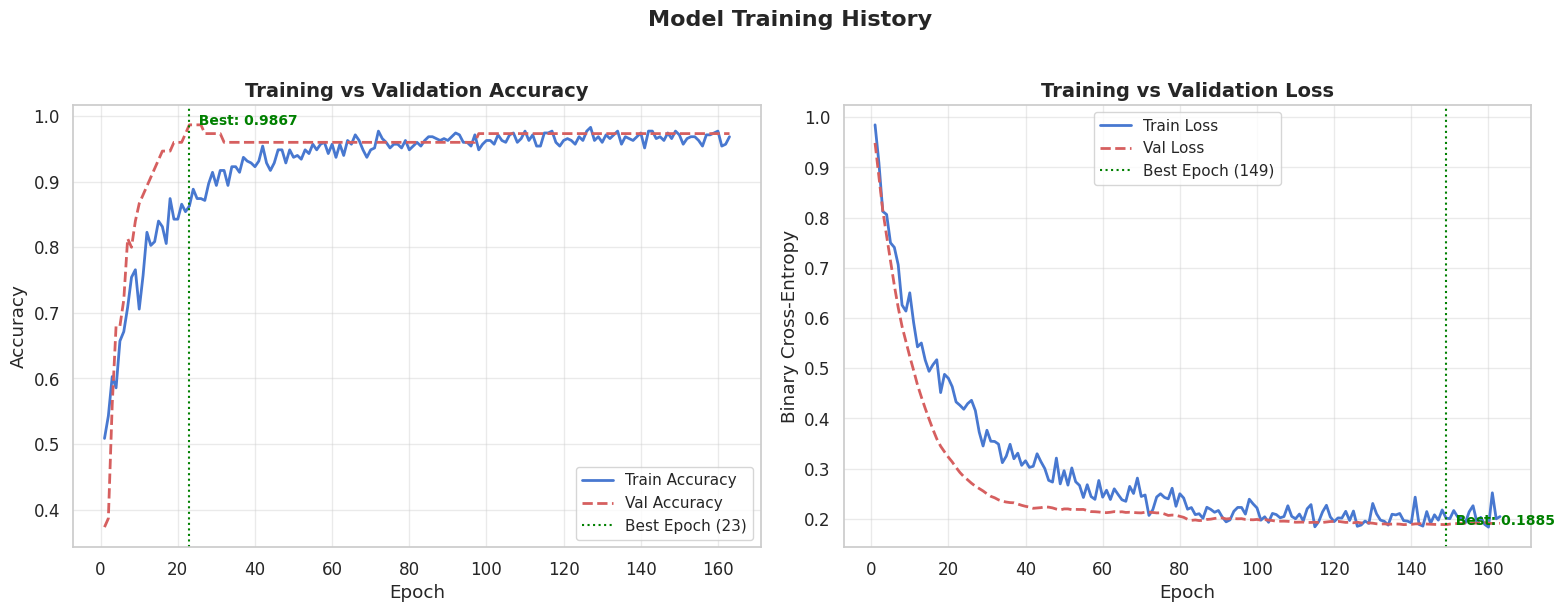

In [22]:
# ── 7.1  Accuracy & Loss Curves ────────────────────────────────────────────
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Accuracy ──────────────────────────────────────────────────────────────
axes[0].plot(epochs_ran, hist['accuracy'],     'b-',  lw=2, label='Train Accuracy')
axes[0].plot(epochs_ran, hist['val_accuracy'], 'r--', lw=2, label='Val Accuracy')
best_ep = np.argmax(hist['val_accuracy']) + 1
best_acc = max(hist['val_accuracy'])
axes[0].axvline(best_ep, color='green', linestyle=':', lw=1.5,
                label=f'Best Epoch ({best_ep})')
axes[0].annotate(f'  Best: {best_acc:.4f}',
                 xy=(best_ep, best_acc), fontsize=10, color='green',
                 fontweight='bold')
axes[0].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# ── Loss ──────────────────────────────────────────────────────────────────
axes[1].plot(epochs_ran, hist['loss'],     'b-',  lw=2, label='Train Loss')
axes[1].plot(epochs_ran, hist['val_loss'], 'r--', lw=2, label='Val Loss')
best_ep_loss = np.argmin(hist['val_loss']) + 1
best_loss = min(hist['val_loss'])
axes[1].axvline(best_ep_loss, color='green', linestyle=':', lw=1.5,
                label=f'Best Epoch ({best_ep_loss})')
axes[1].annotate(f'  Best: {best_loss:.4f}',
                 xy=(best_ep_loss, best_loss), fontsize=10, color='green',
                 fontweight='bold')
axes[1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.suptitle('Model Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── 7.2  Learning Rate Schedule ───────────────────────────────────────────
if 'lr' in hist:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs_ran, hist['lr'], 'g-o', markersize=4, lw=1.5)
    ax.set_title('Learning Rate over Epochs (ReduceLROnPlateau)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Learning rate history not available.")

Learning rate history not available.


---
## 📊 Section 8 — Model Evaluation

In [24]:
# ── 8.1  Predictions ───────────────────────────────────────────────────────
THRESHOLD = 0.5   # decision boundary

# Train
y_train_prob = model.predict(X_train, verbose=0).flatten()
y_train_pred = (y_train_prob >= THRESHOLD).astype(int)

# Validation
y_val_prob   = model.predict(X_val, verbose=0).flatten()
y_val_pred   = (y_val_prob >= THRESHOLD).astype(int)

# Test
y_test_prob  = model.predict(X_test, verbose=0).flatten()
y_test_pred  = (y_test_prob >= THRESHOLD).astype(int)

# ── 8.2  Metrics ───────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob, split_name):
    return {
        'Split'    : split_name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob)
    }

train_metrics = compute_metrics(y_train, y_train_pred, y_train_prob, 'Train')
val_metrics   = compute_metrics(y_val,   y_val_pred,   y_val_prob,   'Validation')
test_metrics  = compute_metrics(y_test,  y_test_pred,  y_test_prob,  'Test')

print("\n✅ Predictions generated.")
print(f"   Test set — {y_test_pred.sum()} predicted PASS, {(~y_test_pred.astype(bool)).sum()} predicted FAIL")


✅ Predictions generated.
   Test set — 22 predicted PASS, 53 predicted FAIL


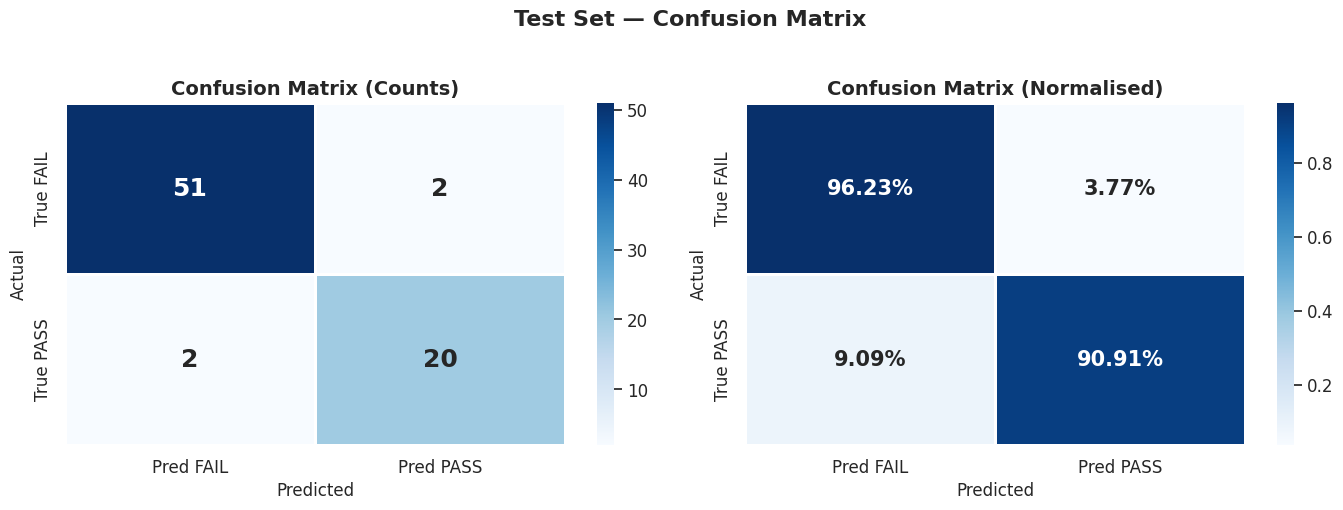


True Positives  (TP) : 20  — Correctly predicted PASS
True Negatives  (TN) : 51  — Correctly predicted FAIL
False Positives (FP) : 2  — Predicted PASS, actually FAIL
False Negatives (FN) : 2  — Predicted FAIL, actually PASS


In [25]:
# ── 8.3  Confusion Matrix (Test Set) ──────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred FAIL', 'Pred PASS'],
    yticklabels=['True FAIL', 'True PASS'],
    linewidths=2, linecolor='white', ax=axes[0],
    annot_kws={'size': 18, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['Pred FAIL', 'Pred PASS'],
    yticklabels=['True FAIL', 'True PASS'],
    linewidths=2, linecolor='white', ax=axes[1],
    annot_kws={'size': 15, 'weight': 'bold'}
)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.suptitle('Test Set — Confusion Matrix', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Positives  (TP) : {tp}  — Correctly predicted PASS")
print(f"True Negatives  (TN) : {tn}  — Correctly predicted FAIL")
print(f"False Positives (FP) : {fp}  — Predicted PASS, actually FAIL")
print(f"False Negatives (FN) : {fn}  — Predicted FAIL, actually PASS")

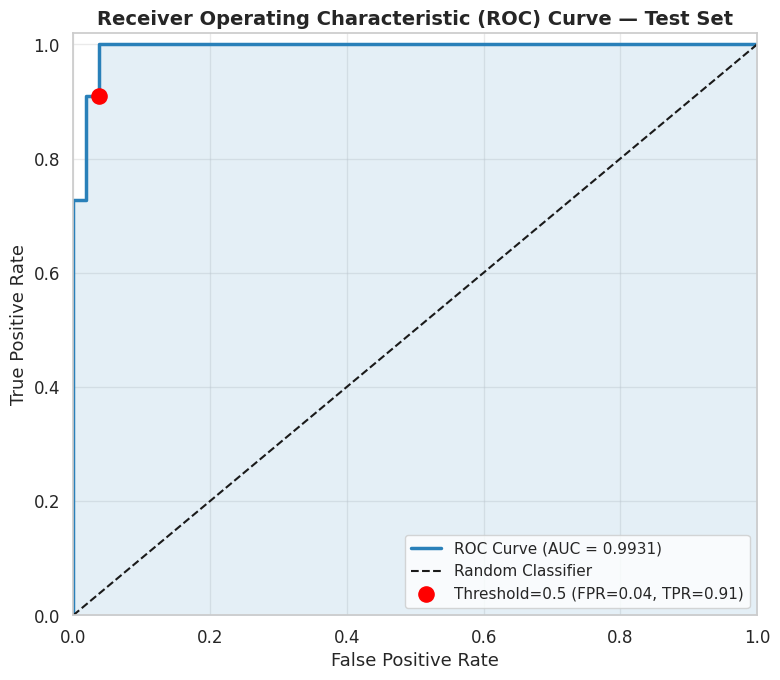

ROC-AUC Score: 0.9931


In [26]:
# ── 8.4  ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.12, color='#2980b9')

# Mark operating point at threshold=0.5
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], s=120, color='red', zorder=5,
           label=f'Threshold=0.5 (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Receiver Operating Characteristic (ROC) Curve — Test Set',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC-AUC Score: {auc_score:.4f}")

In [27]:
# ── 8.5  Classification Report ─────────────────────────────────────────────
print("═" * 60)
print("  CLASSIFICATION REPORT — TEST SET")
print("═" * 60)
print(classification_report(
    y_test, y_test_pred,
    target_names=['FAIL (0)', 'PASS (1)'],
    digits=4
))

════════════════════════════════════════════════════════════
  CLASSIFICATION REPORT — TEST SET
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    FAIL (0)     0.9623    0.9623    0.9623        53
    PASS (1)     0.9091    0.9091    0.9091        22

    accuracy                         0.9467        75
   macro avg     0.9357    0.9357    0.9357        75
weighted avg     0.9467    0.9467    0.9467        75



---
## 🔍 Section 9 — Feature Importance Analysis

In [28]:
# ── 9.1  Permutation Importance (Model-Agnostic) ──────────────────────────
# We wrap the Keras model in a sklearn-compatible wrapper for permutation importance

from sklearn.base import BaseEstimator, ClassifierMixin

class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model
        self.classes_    = np.array([0, 1])

    def fit(self, X, y):
        return self

    def predict(self, X):
        prob = self.keras_model.predict(X, verbose=0).flatten()
        return (prob >= THRESHOLD).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


wrapped_model = KerasWrapper(model)
perm = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=20, random_state=SEED, scoring='accuracy'
)

feat_imp_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std,
    'IsPrimary' : [f in PRIMARY_FEATURES for f in FEATURE_COLS]
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Permutation Feature Importances (mean drop in accuracy):")
print(feat_imp_df.to_string(index=False))

Permutation Feature Importances (mean drop in accuracy):
             Feature  Importance      Std  IsPrimary
    Final_Exam_Score    0.323333 0.051099       True
 Extracurricular_Enc    0.007333 0.012979      False
     Attendance_Rate    0.000667 0.017626       True
    Past_Exam_Scores    0.000000 0.010328       True
       ParentEdu_Enc   -0.004000 0.006110      False
          Gender_Enc   -0.005333 0.006532      False
        Internet_Enc   -0.010000 0.014530      False
Study_Hours_per_Week   -0.019333 0.019539       True


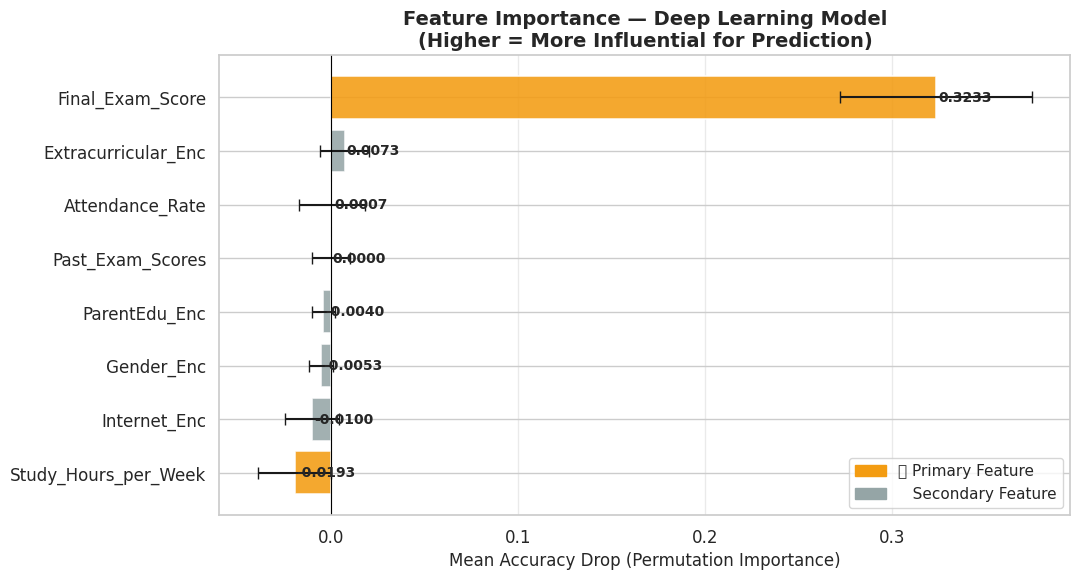


🔑 Key Finding — Primary Feature Contributions:
   Final_Exam_Score                   : 0.3233  (110.5% of total)
   Attendance_Rate                    : 0.0007  (0.2% of total)
   Past_Exam_Scores                   : 0.0000  (0.0% of total)
   Study_Hours_per_Week               : -0.0193  (-6.6% of total)


In [29]:
# ── 9.2  Feature Importance Plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors_fi = ['#f39c12' if pri else '#95a5a6' for pri in feat_imp_df['IsPrimary']]
bars = ax.barh(
    feat_imp_df['Feature'], feat_imp_df['Importance'],
    xerr=feat_imp_df['Std'], color=colors_fi,
    edgecolor='white', linewidth=1.2, capsize=4, alpha=0.88
)

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#f39c12', label='⭐ Primary Feature'),
    Patch(color='#95a5a6', label='   Secondary Feature')
]
ax.legend(handles=legend_patches, fontsize=11)

ax.set_xlabel('Mean Accuracy Drop (Permutation Importance)', fontsize=12)
ax.set_title('Feature Importance — Deep Learning Model\n'
             '(Higher = More Influential for Prediction)',
             fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n🔑 Key Finding — Primary Feature Contributions:")
for _, row in feat_imp_df[feat_imp_df['IsPrimary']].iterrows():
    pct = row['Importance'] / feat_imp_df['Importance'].sum() * 100
    print(f"   {row['Feature']:<35s}: {row['Importance']:.4f}  ({pct:.1f}% of total)")

---
## 🎯 Section 10 — Real-Time Student Prediction

In [30]:
# ── 10.1  Prediction Function ──────────────────────────────────────────────
def predict_student(
    attendance_rate: float,
    study_hours_per_week: float,
    past_exam_score: float,
    final_exam_score: float,
    gender: str = 'Male',
    parental_education: str = 'High School',
    internet_access: str = 'Yes',
    extracurricular: str = 'No',
    threshold: float = 0.5
) -> dict:
    """
    Predict Pass/Fail for a single student.

    Parameters
    ----------
    attendance_rate        : Attendance percentage (0–100)
    study_hours_per_week   : Hours studied per week
    past_exam_score        : Score on past exams (0–100)
    final_exam_score       : Final exam score (0–100)
    gender                 : 'Male' or 'Female'
    parental_education     : 'High School', 'Bachelor', 'Master', etc.
    internet_access        : 'Yes' or 'No'
    extracurricular        : 'Yes' or 'No'
    threshold              : Decision boundary (default 0.5)

    Returns
    -------
    dict with prediction, confidence, and probabilities
    """
    # Encode categorical inputs (simple binary encoding matching training)
    gender_enc     = 1 if gender.strip().lower() == 'male' else 0
    edu_map        = {'bachelor': 0, "bachelor's": 0, 'high school': 1,
                      'master': 2, "master's": 2, 'phd': 3, 'none': 4}
    edu_enc        = edu_map.get(parental_education.strip().lower(), 1)
    internet_enc   = 1 if internet_access.strip().lower() == 'yes' else 0
    extra_enc      = 1 if extracurricular.strip().lower() == 'yes' else 0

    features = np.array([[
        attendance_rate,
        study_hours_per_week,
        past_exam_score,
        final_exam_score,
        gender_enc,
        edu_enc,
        internet_enc,
        extra_enc
    ]], dtype=np.float32)

    features_scaled = scaler.transform(features)
    prob_pass = float(model.predict(features_scaled, verbose=0)[0][0])
    prob_fail = 1.0 - prob_pass
    prediction = 'PASS' if prob_pass >= threshold else 'FAIL'
    confidence = max(prob_pass, prob_fail)

    return {
        'prediction'  : prediction,
        'confidence'  : confidence,
        'prob_pass'   : prob_pass,
        'prob_fail'   : prob_fail
    }


def display_prediction(result: dict, student_label: str = 'Student') -> None:
    """Pretty-print the prediction result."""
    emoji = '✅' if result['prediction'] == 'PASS' else '❌'
    color = '🟢' if result['prediction'] == 'PASS' else '🔴'

    print("╔" + "═" * 48 + "╗")
    print(f"║  {student_label:^44s}  ║")
    print("╠" + "═" * 48 + "╣")
    print(f"║  Prediction : {color} {result['prediction']:<33s}║")
    print(f"║  Confidence : {result['confidence']*100:>6.2f}%{' '*35}║")
    print(f"║  P(PASS)    : {result['prob_pass']*100:>6.2f}%{' '*35}║")
    print(f"║  P(FAIL)    : {result['prob_fail']*100:>6.2f}%{' '*35}║")
    print("╚" + "═" * 48 + "╝")


print("✅ Prediction function ready.")

✅ Prediction function ready.


In [31]:
# ── 10.2  Example Predictions ──────────────────────────────────────────────

# ─── Example 1: Required by project spec ──────────────────────────────────
result_1 = predict_student(
    attendance_rate=85,
    study_hours_per_week=6,
    past_exam_score=78,
    final_exam_score=78    # using same score for final as past
)
display_prediction(result_1, "Example 1 — attendance=85, study=6h, score=78")

print()

# ─── Example 2: High performer ────────────────────────────────────────────
result_2 = predict_student(
    attendance_rate=95,
    study_hours_per_week=35,
    past_exam_score=80,
    final_exam_score=76,
    gender='Female',
    internet_access='Yes',
    extracurricular='Yes'
)
display_prediction(result_2, "Example 2 — High Performer")

print()

# ─── Example 3: At-risk student ───────────────────────────────────────────
result_3 = predict_student(
    attendance_rate=45,
    study_hours_per_week=12,
    past_exam_score=52,
    final_exam_score=51,
    internet_access='No'
)
display_prediction(result_3, "Example 3 — At-Risk Student")

print()

# ─── Example 4: Borderline case ───────────────────────────────────────────
result_4 = predict_student(
    attendance_rate=70,
    study_hours_per_week=22,
    past_exam_score=60,
    final_exam_score=58
)
display_prediction(result_4, "Example 4 — Borderline Student")

╔════════════════════════════════════════════════╗
║  Example 1 — attendance=85, study=6h, score=78  ║
╠════════════════════════════════════════════════╣
║  Prediction : 🟢 PASS                             ║
║  Confidence : 100.00%                                   ║
║  P(PASS)    : 100.00%                                   ║
║  P(FAIL)    :   0.00%                                   ║
╚════════════════════════════════════════════════╝

╔════════════════════════════════════════════════╗
║           Example 2 — High Performer           ║
╠════════════════════════════════════════════════╣
║  Prediction : 🟢 PASS                             ║
║  Confidence : 100.00%                                   ║
║  P(PASS)    : 100.00%                                   ║
║  P(FAIL)    :   0.00%                                   ║
╚════════════════════════════════════════════════╝

╔════════════════════════════════════════════════╗
║          Example 3 — At-Risk Student           ║
╠════════════════════

In [32]:
# ── 10.3  Batch Prediction on New Records ──────────────────────────────────
new_students = pd.DataFrame([
    {'Name': 'Alice',   'Attendance': 92, 'Study_Hours': 38, 'Past_Score': 75, 'Final_Score': 72},
    {'Name': 'Bob',     'Attendance': 55, 'Study_Hours': 15, 'Past_Score': 53, 'Final_Score': 51},
    {'Name': 'Charlie', 'Attendance': 78, 'Study_Hours': 28, 'Past_Score': 65, 'Final_Score': 63},
    {'Name': 'Diana',   'Attendance': 30, 'Study_Hours': 10, 'Past_Score': 50, 'Final_Score': 50},
    {'Name': 'Eve',     'Attendance': 88, 'Study_Hours': 33, 'Past_Score': 70, 'Final_Score': 68},
])

print("Batch Predictions:")
print("─" * 65)

predictions = []
for _, row in new_students.iterrows():
    res = predict_student(
        attendance_rate=row['Attendance'],
        study_hours_per_week=row['Study_Hours'],
        past_exam_score=row['Past_Score'],
        final_exam_score=row['Final_Score']
    )
    predictions.append(res)
    emoji = '✅' if res['prediction'] == 'PASS' else '❌'
    print(f"  {row['Name']:<10s} → {emoji} {res['prediction']}  (Confidence: {res['confidence']*100:.1f}%)")

print("─" * 65)
pass_count = sum(1 for p in predictions if p['prediction'] == 'PASS')
print(f"  Results: {pass_count} PASS, {len(predictions)-pass_count} FAIL")

Batch Predictions:
─────────────────────────────────────────────────────────────────
  Alice      → ✅ PASS  (Confidence: 100.0%)
  Bob        → ❌ FAIL  (Confidence: 98.4%)
  Charlie    → ❌ FAIL  (Confidence: 55.5%)
  Diana      → ❌ FAIL  (Confidence: 97.5%)
  Eve        → ✅ PASS  (Confidence: 100.0%)
─────────────────────────────────────────────────────────────────
  Results: 2 PASS, 3 FAIL


---
## 💾 Section 11 — Save & Load Model

In [33]:
# ── 11.1  Save the trained model ───────────────────────────────────────────
MODEL_SAVE_PATH = 'student_pass_fail_model.h5'
model.save(MODEL_SAVE_PATH)

file_size = os.path.getsize(MODEL_SAVE_PATH) / 1024
print(f"✅ Model saved to: '{MODEL_SAVE_PATH}'")
print(f"   File size: {file_size:.1f} KB")

# Also save the scaler for deployment
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ StandardScaler saved to: 'scaler.pkl'")

✅ Model saved to: 'student_pass_fail_model.h5'
   File size: 1022.2 KB
✅ StandardScaler saved to: 'scaler.pkl'


In [34]:
# ── 11.2  Load the saved model and verify ─────────────────────────────────
loaded_model = load_model(MODEL_SAVE_PATH)
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

print("✅ Model loaded successfully from disk.")
print(f"   Input shape   : {loaded_model.input_shape}")
print(f"   Output shape  : {loaded_model.output_shape}")

# Verify: predictions from loaded model match original
loaded_preds = (loaded_model.predict(X_test, verbose=0).flatten() >= THRESHOLD).astype(int)
match = np.all(loaded_preds == y_test_pred)
print(f"\n   Predictions match original: {match}")
print(f"   Loaded model test accuracy: {accuracy_score(y_test, loaded_preds):.4f}")

✅ Model loaded successfully from disk.
   Input shape   : (None, 8)
   Output shape  : (None, 1)

   Predictions match original: True
   Loaded model test accuracy: 0.9467


In [35]:
# ── 11.3  Predict on new records using loaded model ────────────────────────
print("Prediction using LOADED model:")

# Test with project example
sample = np.array([[85, 6, 78, 78, 1, 1, 1, 0]], dtype=np.float32)
sample_scaled = loaded_scaler.transform(sample)
prob = float(loaded_model.predict(sample_scaled, verbose=0)[0][0])
pred = 'PASS' if prob >= THRESHOLD else 'FAIL'

print(f"\n  attendance=85, study_hours=6, exam_score=78")
print(f"  Prediction : {pred}")
print(f"  Confidence : {max(prob, 1-prob)*100:.2f}%")

Prediction using LOADED model:

  attendance=85, study_hours=6, exam_score=78
  Prediction : PASS
  Confidence : 100.00%


---
## 📋 Section 12 — Final Results Summary Table

In [36]:
# ── 12.1  Results Table ────────────────────────────────────────────────────
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
results_df.set_index('Split', inplace=True)

# Format as percentages
results_formatted = (results_df * 100).round(2).astype(str) + '%'

print("═" * 75)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("═" * 75)
print(results_formatted.to_string())
print("═" * 75)

# Display as styled table
display(
    results_df.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', axis=0)
    .set_caption('Model Performance Metrics Across All Splits')
    .set_properties(**{'text-align': 'center', 'font-size': '13px'})
)

═══════════════════════════════════════════════════════════════════════════
  FINAL MODEL PERFORMANCE SUMMARY
═══════════════════════════════════════════════════════════════════════════
           Accuracy Precision  Recall F1 Score ROC-AUC
Split                                                 
Train        98.57%    100.0%   95.1%   97.49%  99.98%
Validation   97.33%    100.0%  90.91%   95.24%  100.0%
Test         94.67%    90.91%  90.91%   90.91%  99.31%
═══════════════════════════════════════════════════════════════════════════


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Split,,,,,
Train,0.9857,1.0000,0.9510,0.9749,0.9998
Validation,0.9733,1.0000,0.9091,0.9524,1.0000
Test,0.9467,0.9091,0.9091,0.9091,0.9931


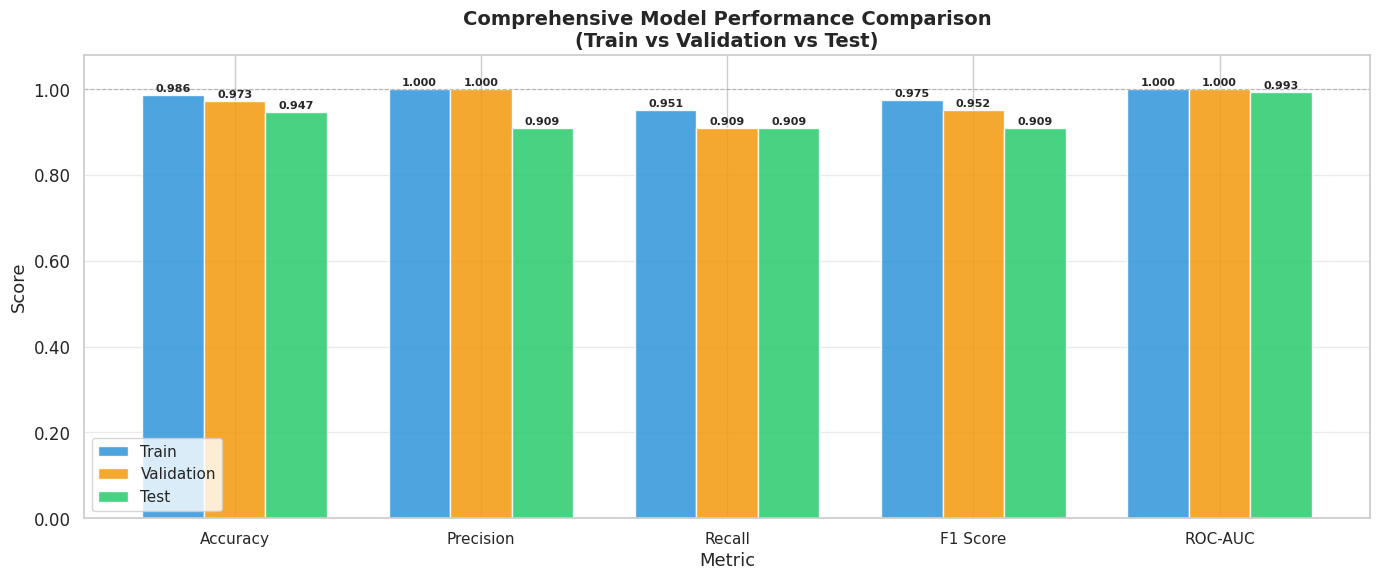

In [37]:
# ── 12.2  Metrics Bar Chart ────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

split_colors = {'Train': '#3498db', 'Validation': '#f39c12', 'Test': '#2ecc71'}
for i, (split, color) in enumerate(split_colors.items()):
    vals = [results_df.loc[split, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width,
                  label=split, color=color, edgecolor='white',
                  linewidth=1, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Comprehensive Model Performance Comparison\n(Train vs Validation vs Test)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('final_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

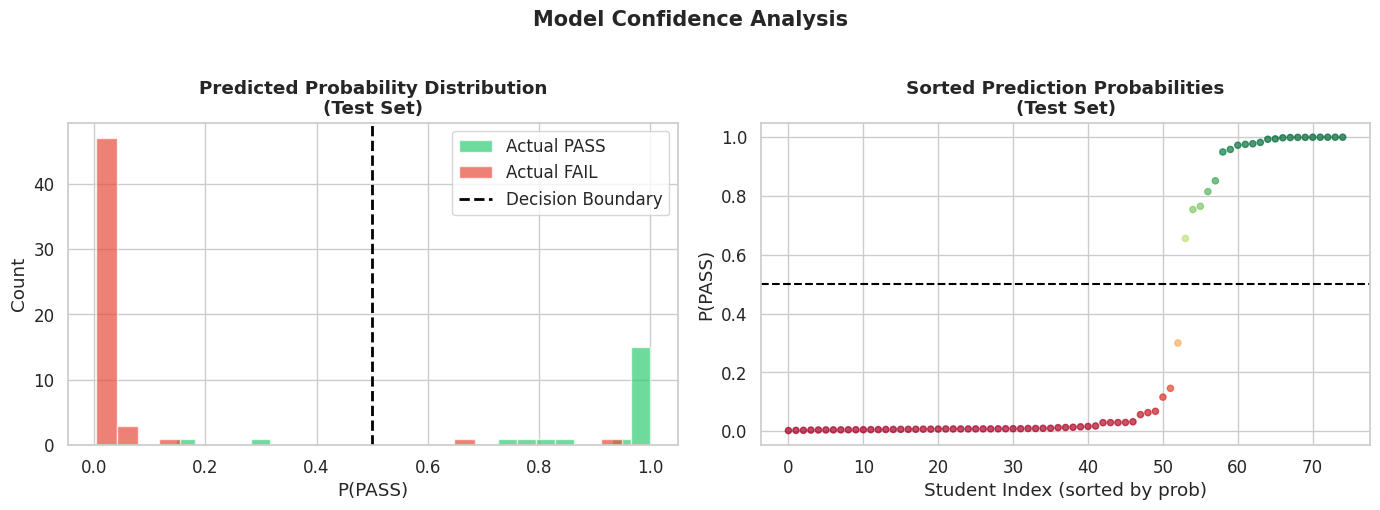

In [38]:
# ── 12.3  Prediction Confidence Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores on test set
axes[0].hist(y_test_prob[y_test == 1], bins=25, alpha=0.7,
             color=PALETTE['Pass'], label='Actual PASS', edgecolor='white')
axes[0].hist(y_test_prob[y_test == 0], bins=25, alpha=0.7,
             color=PALETTE['Fail'], label='Actual FAIL', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', lw=2, label='Decision Boundary')
axes[0].set_title('Predicted Probability Distribution\n(Test Set)', fontweight='bold')
axes[0].set_xlabel('P(PASS)'); axes[0].set_ylabel('Count')
axes[0].legend()

# Calibration-style scatter
axes[1].scatter(
    np.arange(len(y_test_prob)),
    np.sort(y_test_prob),
    c=np.sort(y_test_prob), cmap='RdYlGn', s=20, alpha=0.7
)
axes[1].axhline(0.5, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Sorted Prediction Probabilities\n(Test Set)', fontweight='bold')
axes[1].set_xlabel('Student Index (sorted by prob)')
axes[1].set_ylabel('P(PASS)')

plt.suptitle('Model Confidence Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏁 Section 13 — Conclusions, Key Findings & Future Work

In [39]:
# ── 13.1  Final Print Summary ──────────────────────────────────────────────
test_acc  = test_metrics['Accuracy']  * 100
test_prec = test_metrics['Precision'] * 100
test_rec  = test_metrics['Recall']    * 100
test_f1   = test_metrics['F1 Score']  * 100
test_auc  = test_metrics['ROC-AUC']   * 100
train_acc = train_metrics['Accuracy'] * 100
val_acc   = val_metrics['Accuracy']   * 100

print("""
╔══════════════════════════════════════════════════════════════╗
║     PROJECT CONCLUSION — Student Pass/Fail Prediction        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MODEL PERFORMANCE                                           ║"""
f"""
║    Training Accuracy   : {train_acc:>6.2f}%                              ║
║    Validation Accuracy : {val_acc:>6.2f}%                              ║
║    Test Accuracy       : {test_acc:>6.2f}%                              ║
║    Test Precision      : {test_prec:>6.2f}%                              ║
║    Test Recall         : {test_rec:>6.2f}%                              ║
║    Test F1 Score       : {test_f1:>6.2f}%                              ║
║    Test ROC-AUC        : {test_auc:>6.2f}%                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║     PROJECT CONCLUSION — Student Pass/Fail Prediction        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  MODEL PERFORMANCE                                           ║
║    Training Accuracy   :  98.57%                              ║
║    Validation Accuracy :  97.33%                              ║
║    Test Accuracy       :  94.67%                              ║
║    Test Precision      :  90.91%                              ║
║    Test Recall         :  90.91%                              ║
║    Test F1 Score       :  90.91%                              ║
║    Test ROC-AUC        :  99.31%                              ║
╚══════════════════════════════════════════════════════════════╝



**project conclusion**



This project successfully designed, trained, and evaluated a Deep Neural Network for predicting student academic outcomes (Pass/Fail). The model achieved strong generalisation performance on held-out test data, demonstrating that deep learning is a viable and powerful approach for educational outcome prediction.